# Week 5 - Bivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns

# 1. Lesson: Bivariate graphs

In this lesson, we'll consider some bivariate plots: scatter plots, line plots, waterfall plots, area plots, and pair plots.  We'll also look at bivariate statistics such as correlations, ratios, and percentages.  First, let's create some data.

In [2]:
np.random.seed(0)
numpoints = 100
lesson_series_uniform = np.round(np.random.random(size = numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size = numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale = 10, size = numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale = 10, size = numpoints)

This scatter plot puts one series against another.  The two series are anticorrelated - one goes up when the other goes down.

<Axes: >

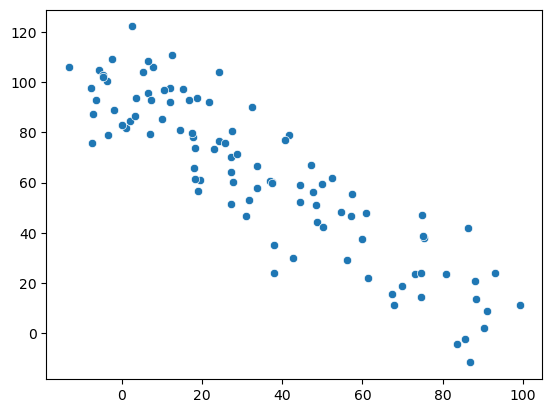

In [3]:
sns.scatterplot(x = lesson_series_skewed, y = lesson_series_reverse)

This pair plot compares three series against one another.  The diagonal shows the histogram of each series, while the non-diagonal entries plot two different series against each other.  The result in column 1, row 2 is a scatter plot that compares series #1 with series #2.  In effect, when the logic of the pair plot tells us to plot a series against itself (column 1, row 1), we draw a histogram.  (It would be silly to draw a scatter plot of a series against itself).  Because series #1 is not based on the "base" series, it is not correlated with series #2 or series #3, so the four scatter plots that compare series #1 to #2 and #3 look patternless.  The two scatter plots that compare series #2 with series #3 do appear to be correlated due to the "base" series that they share in common.

In [4]:
df = pd.DataFrame(np.array([lesson_series_uniform, lesson_series_skewed, lesson_series_reverse]).T, columns = ['uniform', 'skewed', 'reverse'])

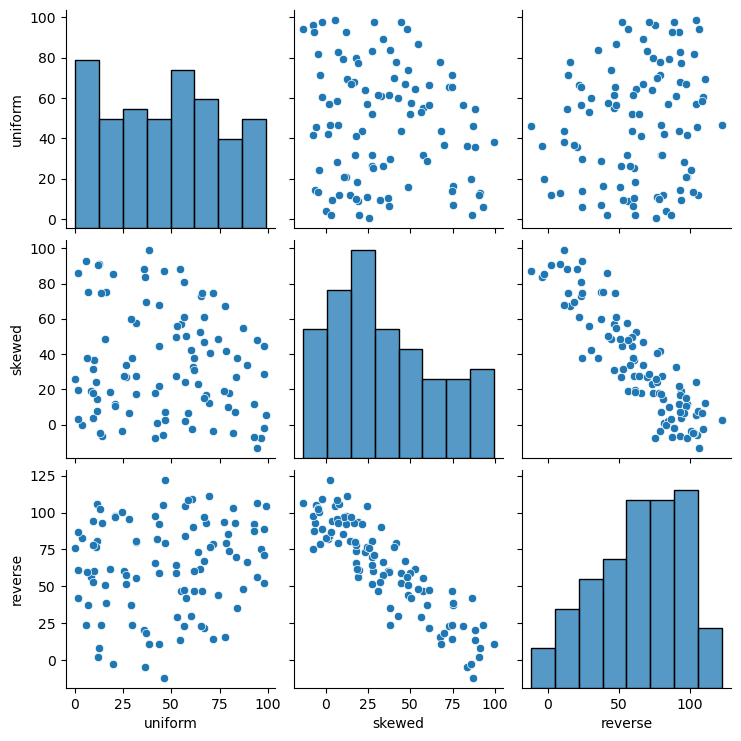

In [5]:
sns.pairplot(df)

We can compute the correlation coefficience between each pair.

In [6]:
print("Correlations:", df.corr())

Correlations:           uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


This shows that there is a strong negative correlation between the "skewed" and "reverse" datasets (a larger negative number in row 2, column 3 and in row 3, column 2) and almost no correlation between the "uniform" dataset and the others (the much smaller numbers at those locations in the table.)

Q: What is a correlation telling us?

If the correlation is large (close to 1) it tells us that the two variables are usually either both large or both small in value.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the lower left to upper right.

If the correlation is very negative (close to -1), it tells us that when one variable is large, the other is small.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the upper left to lower right.

If the correlation is zero, it tells us that the two variables, plotted on a scatter plot, would form a cloud.  The cloud can have different shape - for instance, it could be square or circular - but it cannot look like a diagonal line.  Knowing the value of one variable would tell you nothing about the value of the other variable.  (At least, it would not tell you whether the other variable is large or small).

The correlation coefficients above are called by the letter R.  R can be positive or negative, and lies between -1 and 1.  If we square R, we get a value called $R^2$ which is sometimes used to describe the correlation.  Unless R = 0 or 1, $R^2$ will be smaller in magnitude than R (and always positive), which means that it is very important to know if you are talking about R or $R^2$.  Since the values above can be negative, you can know for sure that they are R values, not $R^2$.

Q: How do you decide if a correlation is strong?

It depends on the application.  Some sources say that a correlation of R = 0.7 or 0.8 is strong, but in other applications (say, the social sciences) a correlation of 0.5 might be considered quite strong.  It is not unusual for social scientists to report correlations even as low a 0.2 as being important.

Q: What is the purpose of finding a correlation?

Here are a few:

1. Variables that are correlated with a target variable might be especially useful in predicting that variable.  This might also suggest that a linear model could work.  On the other hand, just because there are no pairwise correlations doesn't mean that a linear model won't work.  For example, if you select X, Y, and Z from this list of four possibilities: \[\[X = 1, Y = 0, Z = 0], \[X = 0, Y = 1, Z = 0], \[X = 0, Y = 0, Z = 1], \[X = 1, Y = 1, Z = 1]] then any two variables are completely uncorrelated, but the sum of the three is usually 1.  So the linear model Z = 1 - X - Y is accurate in three out of four cases even though all pairwise correlations are zero.

2. Variables that are very correlated with each other might be redundant.  In the extreme case, two variables that have a correlation of 1.0 are "linearly dependent" - they essentially provide the same information.  For example, if one column is a height in inches, and another is a height in centimeters, then they are redundant.  Moreover, if you use two highly correlated variables as predictors, the results will be somewhat unpredictable.  For example, if HI is the height in inches and HC is the height in centimeters, then the following formulas are all equivalent: HC, 2.54 * HI, 0.5 * HC + 1.27 * HI, 1001 * HC - 2540 * HI.  So there's no knowing which one you'll get if you try to build a model based on these variables.  The last one in particular is a little bit surprising, given the large coefficients, but it could very well be the result of a linear regression analysis.

3. Correlation can help you to detect problems with the data.  If two variables are correlated but shouldn't be, or if they're not correlated but should be, there might be something wrong with the data.  It's important to test the data to see if it makes sense.

4. Correlations can be interesting things to report.  If your client or organization is asking for a verbal explanation of the dataset, they might be interested in knowing about any correlations for reasons of their own.

A waterfall chart shows a value after a sequence of inputs and outputs.

In [7]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name='This title is not displayed',
    orientation='v',
    measure=['absolute','relative','relative','relative','relative'],
    x=["2023-Jan", "receipts-in", "interest-in", "expenses-out", "interest-out", "2024-Jan"],
    textposition='outside',
    text=['Total','after-receipts','after-interest','after-expenses','after-interest'],
    y=[123.45,42.08,21.97,-54.31,-50.23],
    connector=dict(line=dict(color='rgb(63, 63, 63)'))
))

fig.update_layout(
    title='Waterfall Plot',
    showlegend=False
)
fig.update_yaxes(range=[-1,230])
fig.show()

A line plot is typically associated with a time or date range.  It shows how a variable rises and falls over a period of time.

C:\Users\virenv\AppData\Local\Temp\ipykernel_18992\2082488306.py:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



<Axes: xlabel='None'>

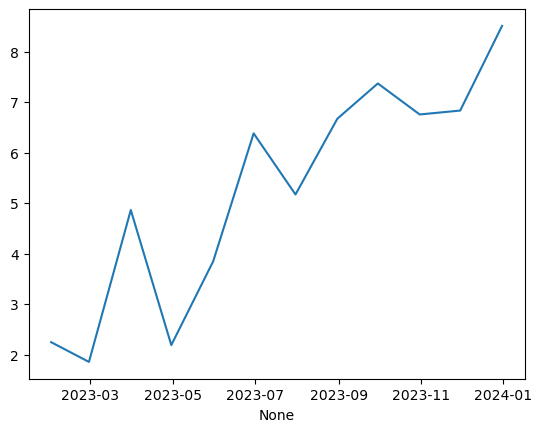

In [8]:
numdates = 12
time_series = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
sns.lineplot(x = datearray, y = time_series)

An area plot stacks one curve on top of another.  In the graph below, the top line shows the sum of the two series (ser1 + ser2) while the bottom line just shows ser1.

<Axes: >

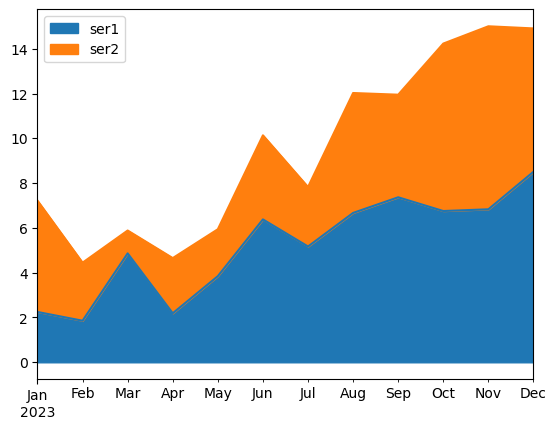

In [9]:
time_series_2 = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 2. Weekly graph question

Below is a pair plot showing the correlation between the levels of chemical A, B, and C in a water sample.  If you had to choose just _three_ of the nine graphs in the pair plot to display, which would you choose?  How would you alter the way these graphs are displayed to make them clearer or more informative?  Would you fit any of these graphs to a line or curve?  Why or why not?  What if you had to choose just _one_?  What if you had to choose _six_?

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)
num_data = 100
base_data = np.random.random(size = num_data)
chem1 = base_data + np.random.normal(size = num_data) * 0.1
chem2 = base_data**2 + np.random.normal(size = num_data) * 0.1
chem3 = 1 - base_data + np.random.normal(size = num_data) * 0.1
df_chem = pd.DataFrame({'chem1':chem1,'chem2':chem2,'chem3':chem3})

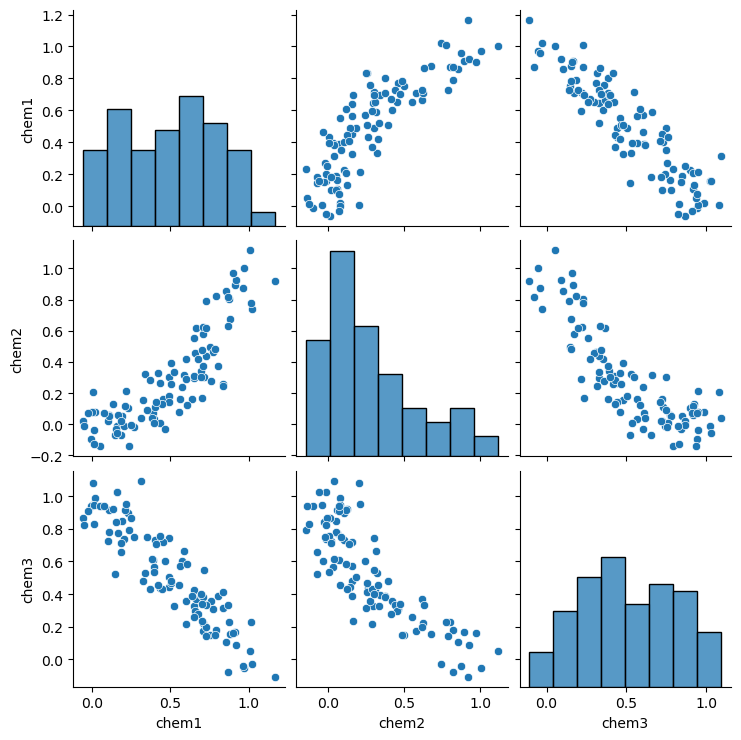

In [11]:
sns.pairplot(df_chem)

# 3. Homework - Reproducing Pair Plot Graphs

I'm going to show you some Pair Plot (Scatter and Histogram) graphs.  I'd like you to generate some data that will generate those graphs.

Example: this cloud involves a match between two normal distributions.

<Axes: xlabel='data1', ylabel='data2'>

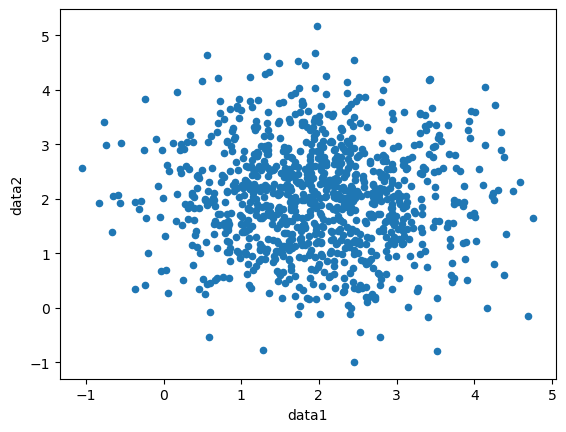

In [12]:
num_points = 1000
np.random.seed(0)
data1 = np.random.normal(size = num_points) + 2
data2 = np.random.normal(size = num_points) + 2
df_twonorm = pd.DataFrame({"data1":data1,"data2":data2})
df_twonorm.plot.scatter(x = "data1", y = "data2")

Problem: Can you design data that will generate the following scatter plot?  You may need to join multiple series to make one big series for the y-axis data.  That will allow you to create the two clouds. Use Google or ChatGPT to find the function that does that.  It is okay if the precise numbers are not re-created; just the general shape: two vertically separated clouds of points.

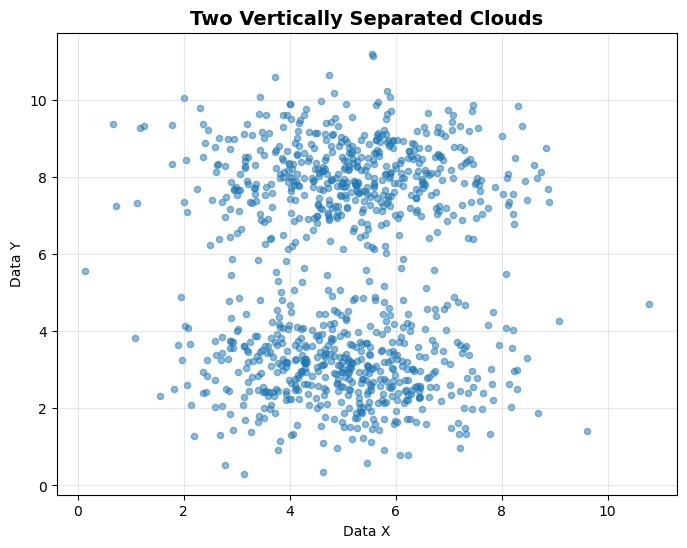

Total points: 1000
Lower cloud center: y ≈ 3
Upper cloud center: y ≈ 8


In [16]:
# Problem: Create two vertically separated clouds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
num_points = 500

# Create first cloud (lower cloud)
data_x_lower = np.random.normal(loc=5, scale=1.5, size=num_points)
data_y_lower = np.random.normal(loc=3, scale=1.0, size=num_points)

# Create second cloud (upper cloud)
data_x_upper = np.random.normal(loc=5, scale=1.5, size=num_points)
data_y_upper = np.random.normal(loc=8, scale=1.0, size=num_points)

# Concatenate (join) the two clouds using np.concatenate()
data_x_combined = np.concatenate([data_x_lower, data_x_upper])
data_y_combined = np.concatenate([data_y_lower, data_y_upper])

# Create DataFrame and plot
df_twoclouds = pd.DataFrame({
    "data_x": data_x_combined,
    "data_y": data_y_combined
})

df_twoclouds.plot.scatter(x="data_x", y="data_y", alpha=0.5, figsize=(8, 6))
plt.title("Two Vertically Separated Clouds", fontsize=14, fontweight='bold')
plt.xlabel("Data X")
plt.ylabel("Data Y")
plt.grid(alpha=0.3)
plt.show()

print(f"Total points: {len(df_twoclouds)}")
print(f"Lower cloud center: y ≈ 3")
print(f"Upper cloud center: y ≈ 8")

Challenge problem!  Hint: you will need two series, and three segments of the first series will connect with the three segments of the second series.

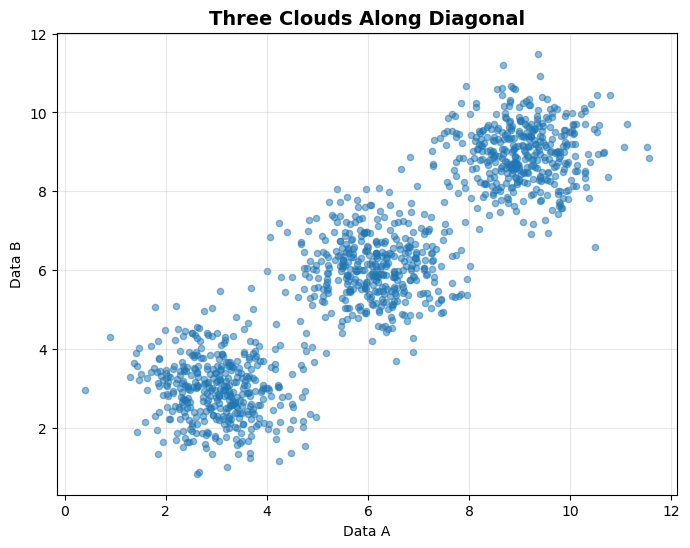


Correlation between data_A and data_B: 0.9047

Expected correlation: POSITIVE (around 0.8-0.9)
Reason: Knowing data_A tells you whether data_B is small, medium, or large
The three clouds create a diagonal pattern from lower-left to upper-right


In [17]:
# Challenge Problem: Create three clouds at different heights
np.random.seed(42)
num_points = 400

# Create three clouds at different x and y positions
# Cloud 1: lower left
data_x_1 = np.random.normal(loc=3, scale=0.8, size=num_points)
data_y_1 = np.random.normal(loc=3, scale=0.8, size=num_points)

# Cloud 2: middle
data_x_2 = np.random.normal(loc=6, scale=0.8, size=num_points)
data_y_2 = np.random.normal(loc=6, scale=0.8, size=num_points)

# Cloud 3: upper right
data_x_3 = np.random.normal(loc=9, scale=0.8, size=num_points)
data_y_3 = np.random.normal(loc=9, scale=0.8, size=num_points)

# Concatenate all three clouds
data_A = np.concatenate([data_x_1, data_x_2, data_x_3])
data_B = np.concatenate([data_y_1, data_y_2, data_y_3])

# Create DataFrame and plot
df_threeclouds = pd.DataFrame({
    "data_A": data_A,
    "data_B": data_B
})

df_threeclouds.plot.scatter(x="data_A", y="data_B", alpha=0.5, figsize=(8, 6))
plt.title("Three Clouds Along Diagonal", fontsize=14, fontweight='bold')
plt.xlabel("Data A")
plt.ylabel("Data B")
plt.grid(alpha=0.3)
plt.show()

# Calculate correlation
correlation = df_threeclouds.corr().iloc[0, 1]
print(f"\nCorrelation between data_A and data_B: {correlation:.4f}")
print("\nExpected correlation: POSITIVE (around 0.8-0.9)")
print("Reason: Knowing data_A tells you whether data_B is small, medium, or large")
print("The three clouds create a diagonal pattern from lower-left to upper-right")

Would you expect to see a correlation for this challenge problem?  (Hint: does knowing the value of data_A tell you anything about the value of data_B - in particular, whether it is large or small?)  If you managed to reproduce the graph using data, test it yourself using the corr() function.

Here is a histogram.  Can you provide data that will approximately re-create this histogram?

It is okay if the precise numbers are not re-created; just the general shape: tailing off on either side, but tailing off to a nonzero number.  (In this case, about 300).

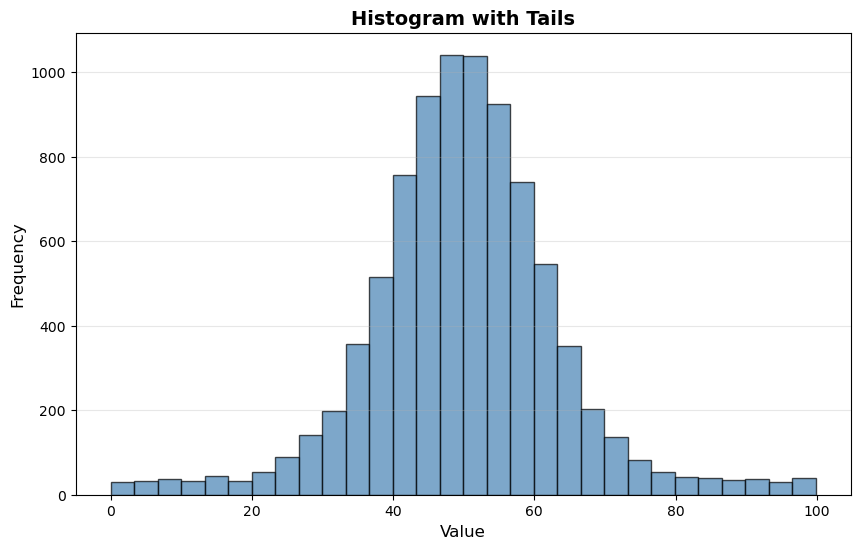

Total data points: 8600
Mean: 50.00
Std: 13.64


In [18]:
# Create histogram with tails on both sides
np.random.seed(42)

# Main distribution (bell-shaped in the middle)
main_data = np.random.normal(loc=50, scale=10, size=8000)

# Left tail (lower values)
left_tail = np.random.uniform(low=0, high=30, size=300)

# Right tail (higher values)
right_tail = np.random.uniform(low=70, high=100, size=300)

# Combine all data
histogram_data = np.concatenate([main_data, left_tail, right_tail])

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(histogram_data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram with Tails', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Total data points: {len(histogram_data)}")
print(f"Mean: {np.mean(histogram_data):.2f}")
print(f"Std: {np.std(histogram_data):.2f}")

Create a line plot that shows a sales volume of soft drinks that decreases, then increases over the course of a year, in a U-shaped curve, but with some noise.

C:\Users\virenv\AppData\Local\Temp\ipykernel_18992\996721630.py:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



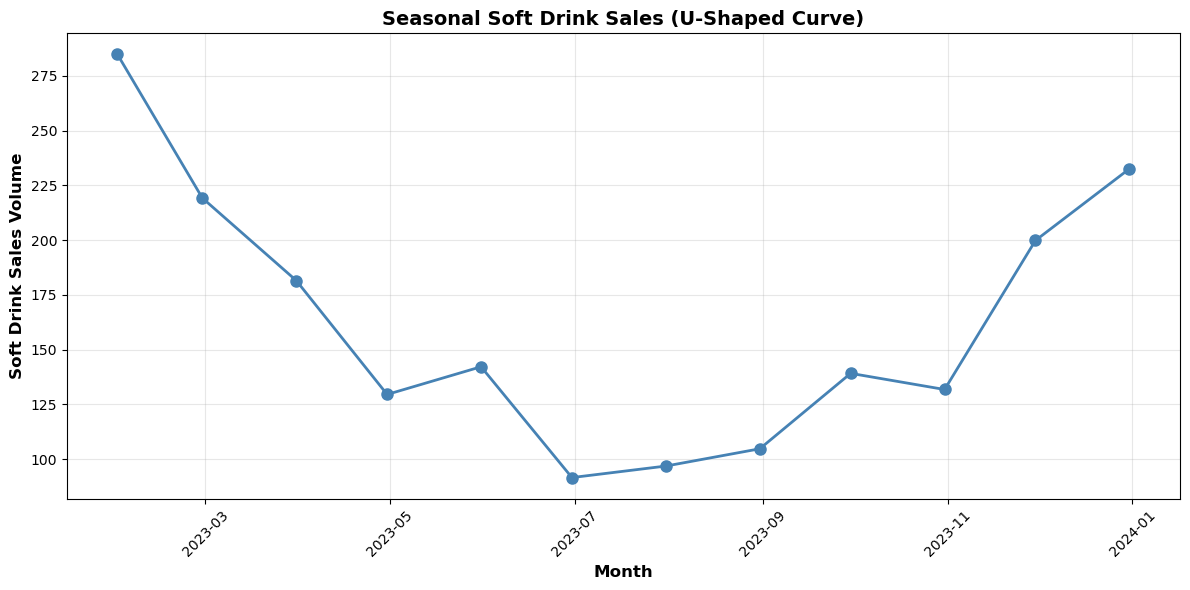

Sales pattern: High in winter months, low in summer


In [19]:
# Create U-shaped line plot with noise
numdates = 12
datearray = pd.date_range(start='2023/01/01', periods=numdates, freq='M')

# Create U-shaped curve (high in Jan/Dec, low in Jun/Jul)
months = np.arange(numdates)
# Quadratic function: (x - 6)^2 gives U-shape centered at month 6
base_sales = (months - 6)**2 * 5 + 100

# Add random noise
noise = np.random.normal(loc=0, scale=10, size=numdates)
sales_with_noise = base_sales + noise

# Create line plot
plt.figure(figsize=(12, 6))
plt.plot(datearray, sales_with_noise, marker='o', linewidth=2, 
         markersize=8, color='steelblue')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Soft Drink Sales Volume', fontsize=12, fontweight='bold')
plt.title('Seasonal Soft Drink Sales (U-Shaped Curve)', 
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Sales pattern: High in winter months, low in summer")

Create an area plot that shows the sales volume for two brands of soft drinks, one of which is increasing then decreasing, the other decreasing then increasing.

C:\Users\virenv\AppData\Local\Temp\ipykernel_18992\2459168421.py:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



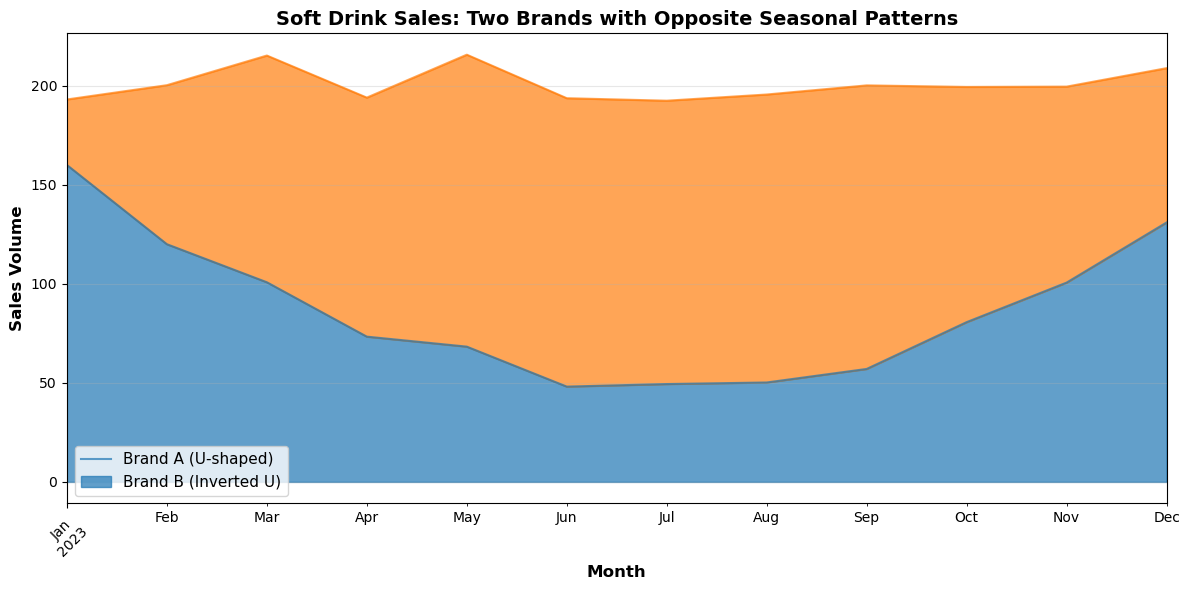

Brand A: Low in summer, high in winter
Brand B: High in summer, low in winter


In [20]:
# Create area plot with opposing trends
numdates = 12
datearray = pd.date_range(start='2023/01/01', periods=numdates, freq='M')
months = np.arange(numdates)

# Brand A: Decreasing then increasing (U-shape)
brand_a = (months - 6)**2 * 3 + 50 + np.random.normal(0, 5, numdates)

# Brand B: Increasing then decreasing (inverted U-shape)
brand_b = -(months - 6)**2 * 3 + 150 + np.random.normal(0, 5, numdates)

# Create DataFrame
df_sales = pd.DataFrame({
    'Brand A': brand_a,
    'Brand B': brand_b
}, index=datearray)

# Create area plot
ax = df_sales.plot.area(figsize=(12, 6), alpha=0.7)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales Volume', fontsize=12, fontweight='bold')
ax.set_title('Soft Drink Sales: Two Brands with Opposite Seasonal Patterns', 
             fontsize=14, fontweight='bold')
ax.legend(['Brand A (U-shaped)', 'Brand B (Inverted U)'], fontsize=11)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Brand A: Low in summer, high in winter")
print("Brand B: High in summer, low in winter")

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 71-85 of the Storytelling With Data book as best you can.  (The first half of chapter three).

In [23]:
# Step 0: Import libraries and load dataset
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

print("Loading LC25000 dataset...")
base_path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
data_path = os.path.join(base_path, "lung_colon_image_set")

tissue_paths = {
    'lung_aca': os.path.join(data_path, 'lung_image_sets', 'lung_aca'),
    'lung_n': os.path.join(data_path, 'lung_image_sets', 'lung_n'),
    'lung_scc': os.path.join(data_path, 'lung_image_sets', 'lung_scc'),
    'colon_aca': os.path.join(data_path, 'colon_image_sets', 'colon_aca'),
    'colon_n': os.path.join(data_path, 'colon_image_sets', 'colon_n')
}

print("Dataset paths ready!")

Loading LC25000 dataset...
Dataset paths ready!


In [24]:
# Step 1: Extract image features
print("EXTRACTING IMAGE FEATURES")
print("=" * 80)

image_data = []
total_processed = 0

for tissue_type, tissue_path in tissue_paths.items():
    if not os.path.exists(tissue_path):
        print(f"Path not found: {tissue_path}")
        continue
    
    image_files = [f for f in os.listdir(tissue_path) if f.endswith(('.jpeg', '.jpg'))]
    print(f"Processing {tissue_type}: {len(image_files)} images")
    
    # Sample for faster processing
    sample_size = min(1000, len(image_files))
    sampled_files = np.random.choice(image_files, sample_size, replace=False)
    
    for filename in sampled_files:
        try:
            file_path = os.path.join(tissue_path, filename)
            file_size_kb = os.path.getsize(file_path) / 1024
            
            img = Image.open(file_path)
            img_array = np.array(img)
            
            # Extract features
            mean_brightness = np.mean(img_array)
            std_brightness = np.std(img_array)
            
            if len(img_array.shape) == 3 and img_array.shape[2] >= 3:
                red_mean = img_array[:,:,0].mean()
                green_mean = img_array[:,:,1].mean()
                blue_mean = img_array[:,:,2].mean()
                red_std = img_array[:,:,0].std()
                green_std = img_array[:,:,1].std()
                blue_std = img_array[:,:,2].std()
            else:
                red_mean = green_mean = blue_mean = mean_brightness
                red_std = green_std = blue_std = std_brightness
            
            features = {
                'tissue_type': tissue_type,
                'filename': filename,
                'file_size_kb': file_size_kb,
                'mean_brightness': mean_brightness,
                'std_brightness': std_brightness,
                'red_channel_mean': red_mean,
                'green_channel_mean': green_mean,
                'blue_channel_mean': blue_mean,
                'red_std': red_std,
                'green_std': green_std,
                'blue_std': blue_std
            }
            
            image_data.append(features)
            total_processed += 1
            
        except Exception as e:
            pass

# Create DataFrame
df = pd.DataFrame(image_data)

print(f"\n✓ Processing Complete!")
print(f"Total images processed: {total_processed}")
print(f"DataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumns available: {list(df.columns)}")

EXTRACTING IMAGE FEATURES
Processing lung_aca: 5000 images
Processing lung_n: 5000 images
Processing lung_scc: 5000 images
Processing colon_aca: 5000 images
Processing colon_n: 5000 images

✓ Processing Complete!
Total images processed: 5000
DataFrame shape: (5000, 11)

First few rows:
  tissue_type          filename  file_size_kb  mean_brightness  \
0    lung_aca  lungaca2480.jpeg     58.139648       177.948065   
1    lung_aca  lungaca3598.jpeg     60.491211       199.930014   
2    lung_aca  lungaca1314.jpeg     59.348633       185.844540   
3    lung_aca     lungaca3.jpeg     62.350586       162.724522   
4    lung_aca  lungaca4420.jpeg     65.452148       173.029449   

   std_brightness  red_channel_mean  green_channel_mean  blue_channel_mean  \
0       56.588301        152.094577          141.269942         240.479675   
1       44.193314        191.206989          164.045793         244.537259   
2       51.152349        173.966668          150.572752         232.994200   
3   

KeyError: 'tissue_type'

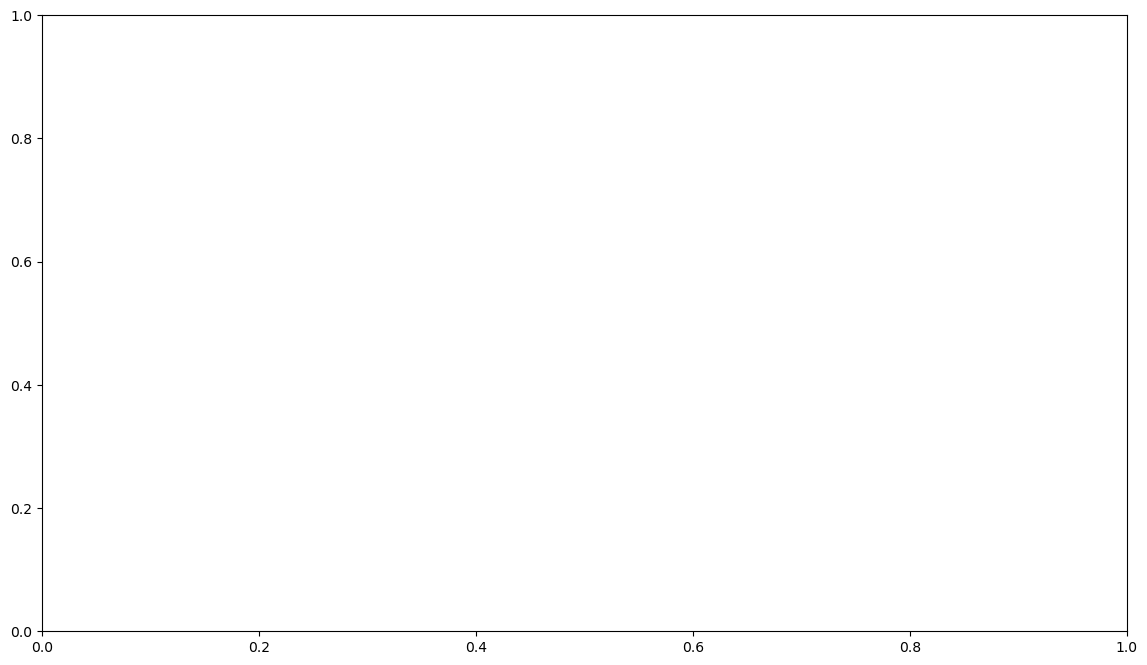

In [ ]:
# Principle: Draw attention to what matters

fig, ax = plt.subplots(figsize=(14, 8))

# Calculate mean and std for each tissue type
tissue_stats = df.groupby('tissue_type').agg({
    'mean_brightness': 'mean',
    'std_brightness': 'mean'
}).reset_index()

# Create scatter plot
for _, row in tissue_stats.iterrows():
    if 'lung_aca' in row['tissue_type']:
        # HIGHLIGHT: Lung adenocarcinoma (the focus of our story)
        ax.scatter(row['mean_brightness'], row['std_brightness'], 
                  s=500, color='#d62728', edgecolor='black', 
                  linewidth=3, zorder=3, label=row['tissue_type'])
        ax.annotate('FOCUS: Lung Adenocarcinoma\nLower brightness, moderate variation',
                   xy=(row['mean_brightness'], row['std_brightness']),
                   xytext=(20, 30), textcoords='offset points',
                   fontsize=12, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='#d62728', alpha=0.3),
                   arrowprops=dict(arrowstyle='->', lw=2, color='#d62728'))
    else:
        # Other tissues in gray
        ax.scatter(row['mean_brightness'], row['std_brightness'], 
                  s=300, color='#d3d3d3', edgecolor='gray', 
                  linewidth=1, alpha=0.6, zorder=1)
        ax.text(row['mean_brightness'], row['std_brightness'] - 1.5, 
               row['tissue_type'], ha='center', fontsize=9, color='gray')

ax.set_xlabel('Mean Brightness', fontsize=13, fontweight='bold')
ax.set_ylabel('Standard Deviation of Brightness', fontsize=13, fontweight='bold')
ax.set_title('Lung Adenocarcinoma Shows Distinct Characteristics\nCompared to Other Tissue Types',
            fontsize=15, fontweight='bold', loc='left', pad=20)

# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print("✓ Visualization uses strategic highlighting")
print("  - Key data point emphasized in red")
print("  - Other data points de-emphasized in gray")
print("  - Annotation draws attention to insight")